# Fire/Smoke Dataset: EDA, Cleaning & Augmentation

This notebook performs Exploratory Data Analysis (EDA), Data Quality Checks, Cleaning, and Image Augmentation on the **Vertex-Test/FireSmokeDataset** from HuggingFace.

The workflow is divided into:
1. **Setup & Data Loading**: Importing required packages and loading the dataset.
2. **Exploratory Data Analysis (EDA)**: Analyzing class distribution, image dimensions, pixel intensity, and aspect ratios.
3. **Data Quality Checks**: Identifying corrupted images and near-duplicate images using perceptual hashing.

In [2]:
import random
import warnings
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
import imagehash

%matplotlib inline
warnings.filterwarnings('ignore')

print("All packages imported successfully.")

All packages imported successfully.


In [3]:
import os, glob
from datasets import Dataset, DatasetDict, Features, Image as ImageFeature, ClassLabel, concatenate_datasets
from huggingface_hub import snapshot_download


# download repo files
repo_path = snapshot_download(
    repo_id ="Vertex-Test/FireSmokeDataset",
    repo_type="dataset",
    allow_patterns=["Data/*"]
)

def create_split(split_name: str) -> Dataset:
    img_dir = os.path.join(repo_path, "Data", split_name, "images")
    lbl_dir = os.path.join(repo_path, "Data", split_name, "labels")
    
    records = []
    
    for img_path in sorted(glob.glob(os.path.join(img_dir, "*.*"))):
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")
        
        label = 0
        if os.path.exists(lbl_path):
            with open(lbl_path, "r") as f:
                lines = f.read().strip().splitlines()
                if lines:
                    label = int(lines[0].split()[0])
        records.append({"image": img_path, "label": label})
    
    features = Features({"image": ImageFeature(), "label" : ClassLabel(names=["fire", "smoke"])})
    return Dataset.from_list(records, features=features)

# Load the dataset from HuggingFace
ds = DatasetDict({
    "train": create_split("train"),
    "validation": create_split("valid"),
    "test": create_split("test")
})

print("--- Dataset Summary ---")
print(ds)
print("\n--- Features ---")
print(ds['train'].features)
print(f"\nTotal train samples: {len(ds['train'])}")


Fetching 18187 files: 100%|██████████| 18187/18187 [00:30<00:00, 603.15it/s]


--- Dataset Summary ---
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7468
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 813
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 812
    })
})

--- Features ---
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['fire', 'smoke'])}

Total train samples: 7468


## 2. Exploratory Data Analysis

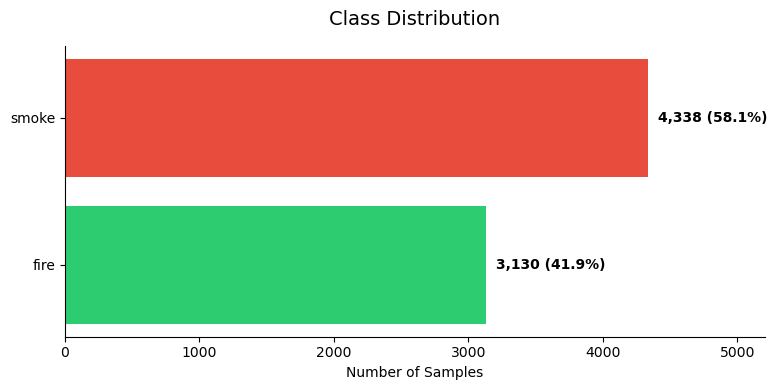

In [4]:
# Class distribution analysis
train_data = ds['train']
labels = train_data['label']
class_names = train_data.features['label'].names
label_counts = Counter(labels)

total_samples = len(labels)
counts = [label_counts[i] for i in range(len(class_names))]
percentages = [(c / total_samples) * 100 for c in counts]

colors = ['#2ecc71', '#e74c3c', '#95a5a6'][:len(class_names)]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(class_names, counts, color=colors)

for bar, count, pct in zip(bars, counts, percentages):
    ax.text(bar.get_width() + total_samples * 0.01, bar.get_y() + bar.get_height()/2, 
            f'{count:,} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')

ax.set_title('Class Distribution', fontsize=14, pad=15)
ax.set_xlabel('Number of Samples')
ax.set_xlim(0, max(counts) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

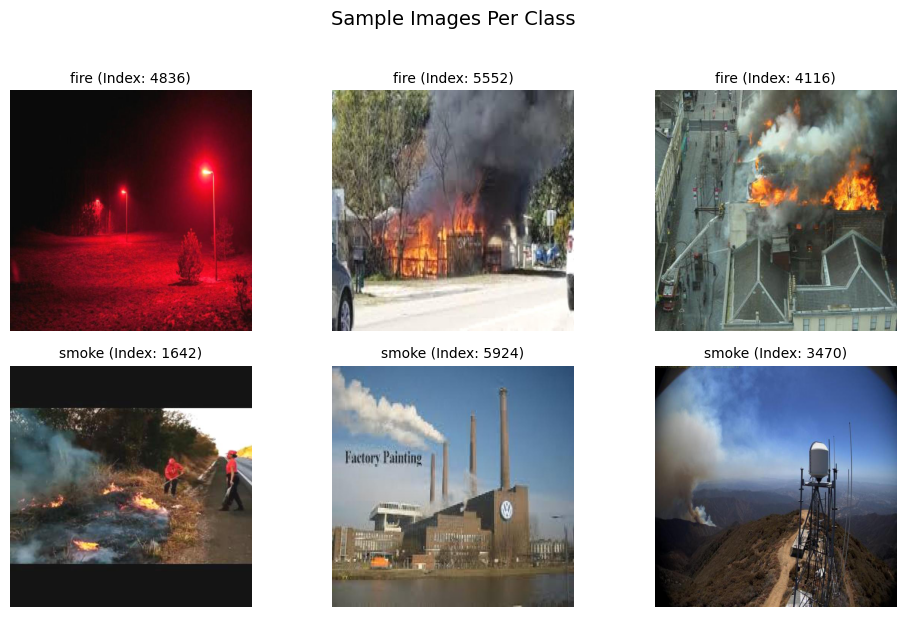

In [5]:
# Sample image grid: show 3 random images per class
num_samples_per_class = 3
num_classes = len(class_names)

fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(10, 3 * num_classes))

for class_idx, name in enumerate(class_names):
    # Find all indices for this class
    class_indices = [i for i, label in enumerate(labels) if label == class_idx]
    sampled_indices = random.sample(class_indices, min(num_samples_per_class, len(class_indices)))
    
    for sample_idx, idx in enumerate(sampled_indices):
        ax = axes[class_idx, sample_idx] if num_classes > 1 else axes[sample_idx]
        img = train_data[idx]['image']
        ax.imshow(img)
        ax.set_title(f"{name} (Index: {idx})", fontsize=10)
        ax.axis('off')

plt.suptitle("Sample Images Per Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

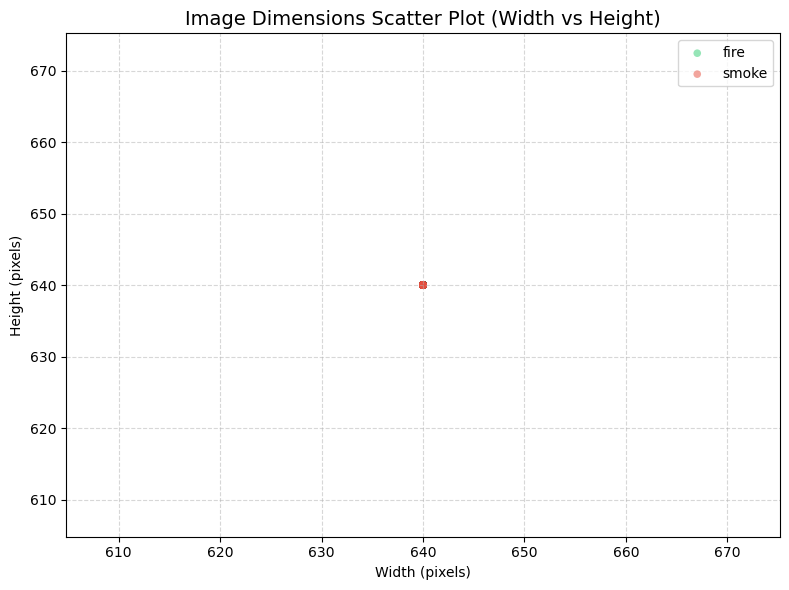

In [6]:
# Image dimension scatter plot (Width vs Height)
widths = []
heights = []
class_labels = []

for item in train_data:
    img = item['image']
    widths.append(img.width)
    heights.append(img.height)
    class_labels.append(item['label'])

widths = np.array(widths)
heights = np.array(heights)
class_labels = np.array(class_labels)

plt.figure(figsize=(8, 6))
color_map = ['#2ecc71', '#e74c3c', '#95a5a6']

for class_idx, name in enumerate(class_names):
    mask = (class_labels == class_idx)
    plt.scatter(widths[mask], heights[mask], label=name, alpha=0.5, c=color_map[class_idx % len(color_map)], edgecolors='none', s=30)

plt.title('Image Dimensions Scatter Plot (Width vs Height)', fontsize=14)
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

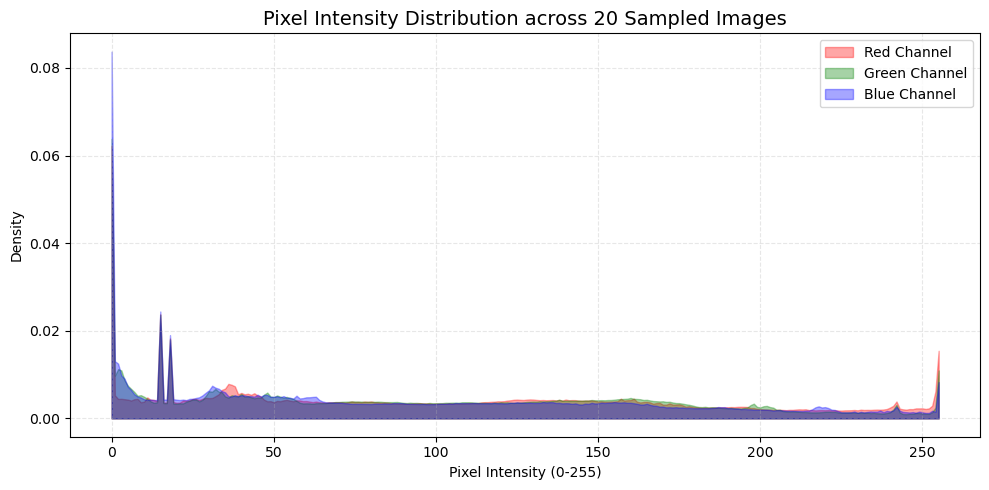

In [7]:
# Pixel intensity histograms (R, G, B channels — lightweight 20-image sample)
sample_size = min(20, len(train_data))
sample_indices = random.sample(range(len(train_data)), sample_size)

r_hist = np.zeros(256, dtype=np.int64)
g_hist = np.zeros(256, dtype=np.int64)
b_hist = np.zeros(256, dtype=np.int64)

for idx in sample_indices:
    arr = np.array(train_data[idx]['image'].convert('RGB'))
    r_hist += np.bincount(arr[:, :, 0].ravel(), minlength=256)
    g_hist += np.bincount(arr[:, :, 1].ravel(), minlength=256)
    b_hist += np.bincount(arr[:, :, 2].ravel(), minlength=256)

# Normalize to density
total_px = r_hist.sum()
bins = np.arange(256)

plt.figure(figsize=(10, 5))
plt.fill_between(bins, r_hist / total_px, color='red', alpha=0.35, label='Red Channel')
plt.fill_between(bins, g_hist / total_px, color='green', alpha=0.35, label='Green Channel')
plt.fill_between(bins, b_hist / total_px, color='blue', alpha=0.35, label='Blue Channel')

plt.title(f'Pixel Intensity Distribution across {sample_size} Sampled Images', fontsize=14)
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

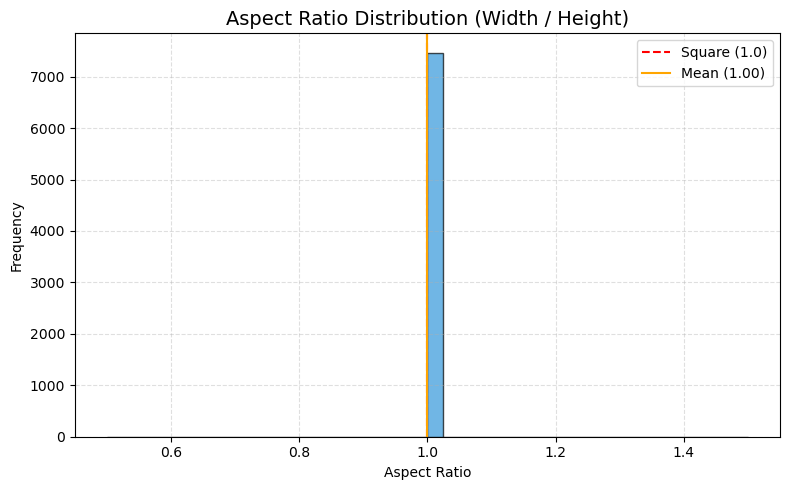

In [8]:
# Aspect ratio histogram (Width / Height ratio)
aspect_ratios = widths / heights

plt.figure(figsize=(8, 5))
plt.hist(aspect_ratios, bins=40, color='#3498db', edgecolor='black', alpha=0.7)
plt.axvline(1.0, color='red', linestyle='--', label='Square (1.0)')
plt.axvline(np.mean(aspect_ratios), color='orange', linestyle='-', label=f'Mean ({np.mean(aspect_ratios):.2f})')

plt.title('Aspect Ratio Distribution (Width / Height)', fontsize=14)
plt.xlabel('Aspect Ratio')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [9]:
# Summary statistics printout
resolutions = [(w, h) for w, h in zip(widths, heights)]
unique_resolutions = set(resolutions)

max_count = max(counts)
min_count = min(counts)
imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

print("=" * 45)
print("       DATASET EXPLORATORY SUMMARY STATS       ")
print("=" * 45)
print(f"Total images analyzed      : {len(train_data)}")
print(f"Unique dimensions (W x H)  : {len(unique_resolutions)}")
print(f"Min resolution (W x H)     : {min(widths)} x {min(heights)}")
print(f"Max resolution (W x H)     : {max(widths)} x {max(heights)}")
print(f"Mean resolution (W x H)    : {np.mean(widths):.1f} x {np.mean(heights):.1f}")
print(f"Mean aspect ratio          : {np.mean(aspect_ratios):.2f}")
print(f"Class imbalance ratio      : {imbalance_ratio:.2f}:1")
print("=" * 45)

       DATASET EXPLORATORY SUMMARY STATS       
Total images analyzed      : 7468
Unique dimensions (W x H)  : 1
Min resolution (W x H)     : 640 x 640
Max resolution (W x H)     : 640 x 640
Mean resolution (W x H)    : 640.0 x 640.0
Mean aspect ratio          : 1.00
Class imbalance ratio      : 1.39:1


## 3. Data Quality Checks

In [10]:
# Corrupted image detection
corrupted_indices = []

for idx, item in enumerate(train_data):
    try:
        img = item['image']
        # Try converting to RGB and loading pixel data
        rgb_img = img.convert('RGB')
        rgb_img.load()
    except Exception as e:
        print(f"Corrupted image found at index {idx}: {e}")
        corrupted_indices.append(idx)

print(f"Total corrupted images found: {len(corrupted_indices)}")

Total corrupted images found: 0


Total duplicate pairs found (Hamming dist <= 4): 44452
Unique duplicate images flagged for removal: 5514


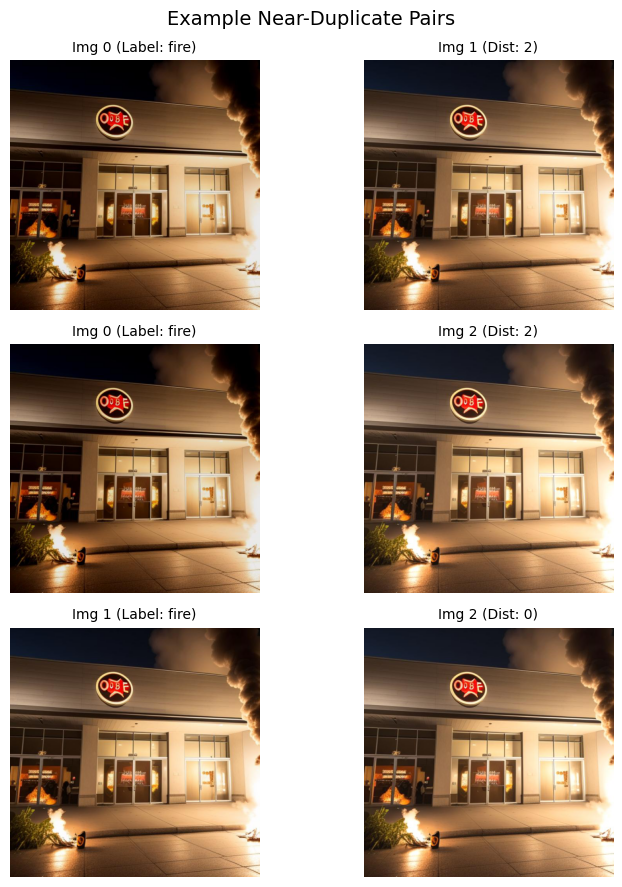

In [11]:
# Near-duplicate detection using imagehash.phash()
hashes = {}
duplicate_pairs = []

# Compute perceptual hash for all images
for idx, item in enumerate(train_data):
    try:
        img = item['image'].convert('RGB')
        h = imagehash.phash(img)
        hashes[idx] = h
    except Exception:
        continue

# Find pairs with hamming distance <= 4
hash_items = list(hashes.items())
flagged_duplicates = set()

for i in range(len(hash_items)):
    idx1, h1 = hash_items[i]
    for j in range(i + 1, len(hash_items)):
        idx2, h2 = hash_items[j]
        distance = h1 - h2
        if distance <= 4:
            duplicate_pairs.append((idx1, idx2, distance))
            flagged_duplicates.add(idx2)

print(f"Total duplicate pairs found (Hamming dist <= 4): {len(duplicate_pairs)}")
print(f"Unique duplicate images flagged for removal: {len(flagged_duplicates)}")

# Display up to 3 example duplicate pairs if found
if duplicate_pairs:
    examples_to_show = min(3, len(duplicate_pairs))
    fig, axes = plt.subplots(examples_to_show, 2, figsize=(8, 3 * examples_to_show))
    
    for row in range(examples_to_show):
        idx1, idx2, dist = duplicate_pairs[row]
        ax1 = axes[row, 0] if examples_to_show > 1 else axes[0]
        ax2 = axes[row, 1] if examples_to_show > 1 else axes[1]
        
        ax1.imshow(train_data[idx1]['image'])
        ax1.set_title(f"Img {idx1} (Label: {class_names[train_data[idx1]['label']]})", fontsize=10)
        ax1.axis('off')
        
        ax2.imshow(train_data[idx2]['image'])
        ax2.set_title(f"Img {idx2} (Dist: {dist})", fontsize=10)
        ax2.axis('off')
        
    plt.suptitle("Example Near-Duplicate Pairs", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No near-duplicate image pairs detected with Hamming distance <= 4.")

In [12]:
# Store indices to remove (corrupted + duplicates)
indices_to_remove = set(corrupted_indices).union(set(flagged_duplicates))

print("=" * 45)
print("        DATA QUALITY REMOVAL SUMMARY        ")
print("=" * 45)
print(f"Corrupted image indices  : {len(corrupted_indices)}")
print(f"Duplicate image indices  : {len(flagged_duplicates)}")
print(f"Total indices to remove  : {len(indices_to_remove)}")
print(f"Remaining clean samples  : {len(train_data) - len(indices_to_remove)}")
print("=" * 45)

        DATA QUALITY REMOVAL SUMMARY        
Corrupted image indices  : 0
Duplicate image indices  : 5514
Total indices to remove  : 5514
Remaining clean samples  : 1954


## 4. Cleaning & Normalization

In [13]:
# Filter out corrupted and duplicate image indices
valid_indices = [i for i in range(len(ds['train'])) if i not in indices_to_remove]
ds_clean = ds['train'].select(valid_indices)

print(f"Original dataset size: {len(ds['train'])} samples")
print(f"Removed indices count: {len(indices_to_remove)}")
print(f"Cleaned dataset size:  {len(ds_clean)} samples")

Original dataset size: 7468 samples
Removed indices count: 5514
Cleaned dataset size:  1954 samples


In [14]:
# Resize all images to 224x224 RGB using LANCZOS resampling
def preprocess_image(example):
    img = example['image']
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img_resized = img.resize((224, 224), Image.Resampling.LANCZOS)
    example['image'] = img_resized
    return example

ds_clean = ds_clean.map(preprocess_image)
print(f"Resized all {len(ds_clean)} images to 224x224 RGB format.")

Map:   0%|          | 0/1954 [00:00<?, ? examples/s]

Map: 100%|██████████| 1954/1954 [01:51<00:00, 17.59 examples/s]

Resized all 1954 images to 224x224 RGB format.


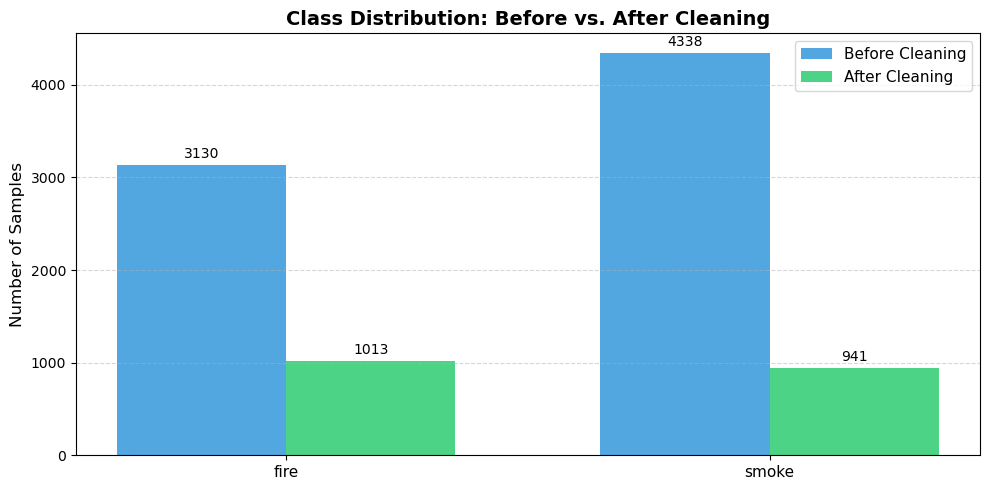

In [15]:
%matplotlib inline

# Compute class counts before and after cleaning
labels_before = [example['label'] for example in ds['train']]
labels_after = [example['label'] for example in ds_clean]

counts_before = Counter(labels_before)
counts_after = Counter(labels_after)

if hasattr(ds['train'].features['label'], 'names'):
    class_names = ds['train'].features['label'].names
else:
    unique_labels = sorted(list(set(labels_before)))
    class_names = [str(lbl) for lbl in unique_labels]

classes = range(len(class_names))
before_vals = [counts_before[c] for c in classes]
after_vals = [counts_after[c] for c in classes]

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, before_vals, width, label='Before Cleaning', color='#3498db', alpha=0.85)
rects2 = ax.bar(x + width/2, after_vals, width, label='After Cleaning', color='#2ecc71', alpha=0.85)

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution: Before vs. After Cleaning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.bar_label(rects1, padding=3, fontsize=10)
ax.bar_label(rects2, padding=3, fontsize=10)

plt.tight_layout()
plt.show()

## 5. Data Augmentation (Class Balancing)

In [16]:
def augment_image(img):
    """
    Applies random augmentations to a PIL Image:
    - Horizontal flip (50% probability)
    - Random rotation (-15 to +15 degrees)
    - Brightness adjustment (factor 0.8 to 1.2)
    - Contrast adjustment (factor 0.8 to 1.2)
    - Gaussian blur (radius 0 to 1.5, 30% probability)
    """
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # 1. Horizontal flip
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
        
    # 2. Random rotation (+-15 deg)
    angle = random.uniform(-15, 15)
    img = img.rotate(angle, resample=Image.BICUBIC, expand=False)
    
    # 3. Brightness adjustment
    b_factor = random.uniform(0.8, 1.2)
    img = ImageEnhance.Brightness(img).enhance(b_factor)
    
    # 4. Contrast adjustment
    c_factor = random.uniform(0.8, 1.2)
    img = ImageEnhance.Contrast(img).enhance(c_factor)
    
    # 5. Gaussian blur (30% probability)
    if random.random() < 0.3:
        blur_radius = random.uniform(0.0, 1.5)
        img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        
    return img

In [17]:
# Count occurrences per class in cleaned dataset
cleaned_labels = [example['label'] for example in ds_clean]
label_counts = Counter(cleaned_labels)
target_count = max(label_counts.values())

print(f"Target count per class for balancing: {target_count}")
print(f"Per-class counts before augmentation: {dict(label_counts)}")

# Group images by label
class_images = {c: [] for c in label_counts.keys()}
for example in ds_clean:
    class_images[example['label']].append(example['image'])

augmented_data = {'image': [], 'label': []}

for label, count in label_counts.items():
    needed = target_count - count
    if needed > 0:
        source_imgs = class_images[label]
        for i in range(needed):
            base_img = random.choice(source_imgs)
            aug_img = augment_image(base_img)
            augmented_data['image'].append(aug_img)
            augmented_data['label'].append(label)

if augmented_data['image']:
    ds_new_samples = Dataset.from_dict(augmented_data, features=ds_clean.features)
    ds_augmented = concatenate_datasets([ds_clean, ds_new_samples])
else:
    ds_augmented = ds_clean

final_labels = [example['label'] for example in ds_augmented]
final_counts = Counter(final_labels)

print(f"Per-class counts after augmentation:  {dict(final_counts)}")
print(f"Total dataset size after augmentation: {len(ds_augmented)}")

Target count per class for balancing: 1013
Per-class counts before augmentation: {0: 1013, 1: 941}
Per-class counts after augmentation:  {0: 1013, 1: 1013}
Total dataset size after augmentation: 2026


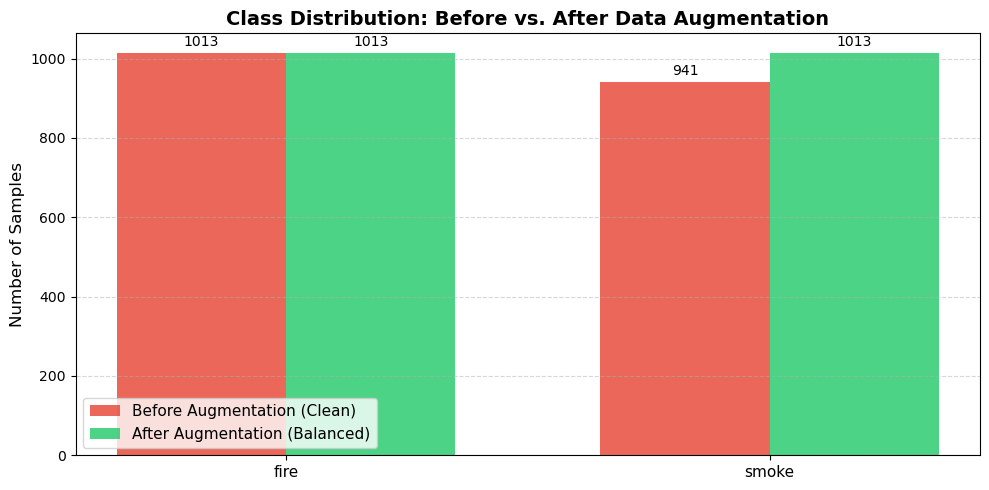

In [18]:
%matplotlib inline

before_aug_counts = Counter([example['label'] for example in ds_clean])
after_aug_counts = Counter([example['label'] for example in ds_augmented])

if hasattr(ds['train'].features['label'], 'names'):
    class_names = ds['train'].features['label'].names
else:
    unique_labels = sorted(list(set(before_aug_counts.keys())))
    class_names = [str(lbl) for lbl in unique_labels]

classes = range(len(class_names))
vals_before = [before_aug_counts[c] for c in classes]
vals_after = [after_aug_counts[c] for c in classes]

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, vals_before, width, label='Before Augmentation (Clean)', color='#e74c3c', alpha=0.85)
rects2 = ax.bar(x + width/2, vals_after, width, label='After Augmentation (Balanced)', color='#2ecc71', alpha=0.85)

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution: Before vs. After Data Augmentation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.bar_label(rects1, padding=3, fontsize=10)
ax.bar_label(rects2, padding=3, fontsize=10)

plt.tight_layout()
plt.show()

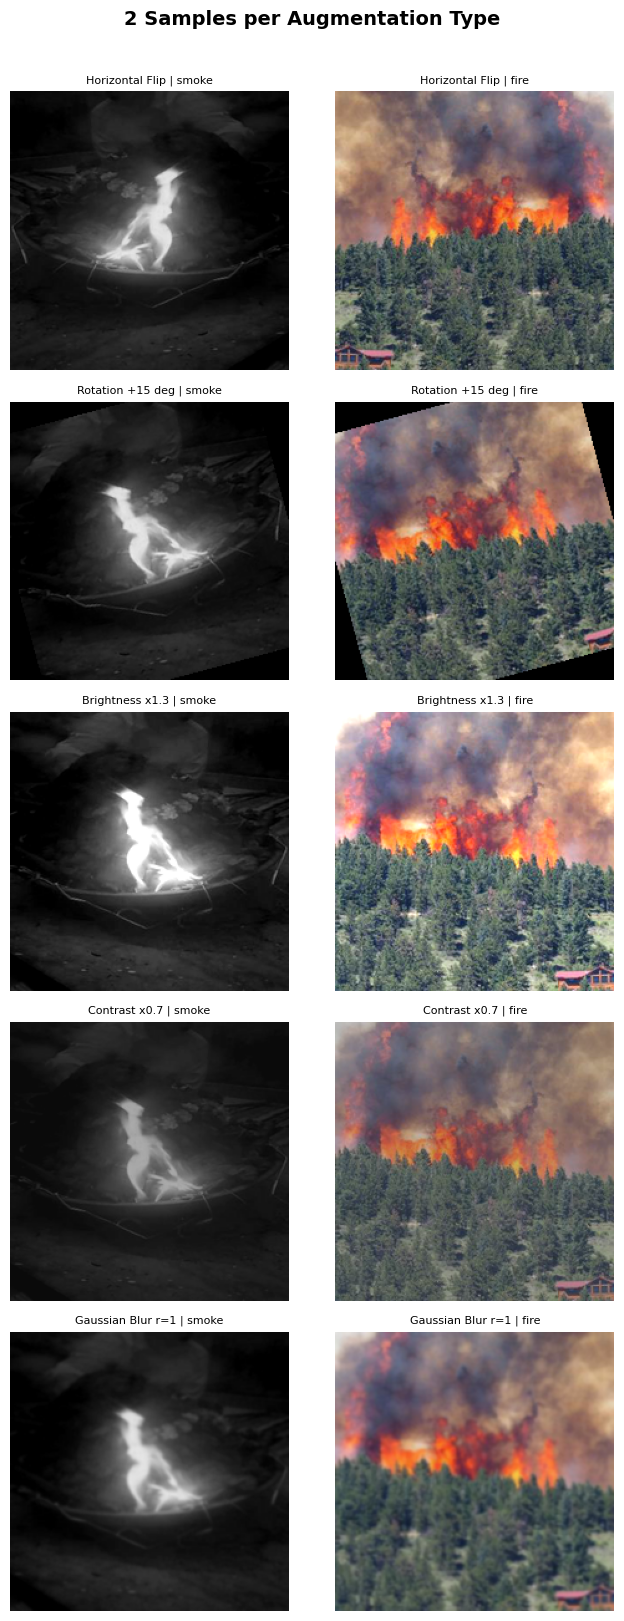

In [19]:
%matplotlib inline

augmentation_types = [
    ("Horizontal Flip",    lambda img: img.transpose(Image.FLIP_LEFT_RIGHT)),
    ("Rotation +15 deg",   lambda img: img.rotate(15, resample=Image.BICUBIC, expand=False)),
    ("Brightness x1.3",    lambda img: ImageEnhance.Brightness(img).enhance(1.3)),
    ("Contrast x0.7",      lambda img: ImageEnhance.Contrast(img).enhance(0.7)),
    ("Gaussian Blur r=1",  lambda img: img.filter(ImageFilter.GaussianBlur(radius=1))),
]

n_augs = len(augmentation_types)
n_samples = 2

# Pick n_samples base images from ds_augmented
base_indices = random.sample(range(len(ds_augmented)), n_samples)
base_imgs = []
base_labels = []
for idx in base_indices:
    sample = ds_augmented[idx]
    img = sample["image"]
    if img.mode != "RGB":
        img = img.convert("RGB")
    lbl = sample["label"]
    if hasattr(ds["train"].features["label"], "names"):
        lbl_str = ds["train"].features["label"].names[lbl]
    else:
        lbl_str = f"Class {lbl}"
    base_imgs.append(img)
    base_labels.append(lbl_str)

fig, axes = plt.subplots(n_augs, n_samples, figsize=(n_samples * 3.5, n_augs * 3.2))
fig.suptitle("2 Samples per Augmentation Type", fontsize=14, fontweight="bold", y=1.01)

for row, (aug_name, aug_fn) in enumerate(augmentation_types):
    for col in range(n_samples):
        ax = axes[row][col]
        aug_img = aug_fn(base_imgs[col])
        ax.imshow(aug_img)
        title = aug_name + " | " + base_labels[col]
        ax.set_title(title, fontsize=8)
        ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Summary & Handoff

In [22]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def normalize(img_array):
    return (img_array / 255.0 - IMAGENET_MEAN) / IMAGENET_STD

print("Normalization utility defined:")
print(f"  IMAGENET_MEAN: {IMAGENET_MEAN}")
print(f"  IMAGENET_STD:  {IMAGENET_STD}")
print("Note: Apply normalization at training time or during batch collation.")

Normalization utility defined:
  IMAGENET_MEAN: [0.485 0.456 0.406]
  IMAGENET_STD:  [0.229 0.224 0.225]
Note: Apply normalization at training time or during batch collation.


In [23]:
ds_final = ds_augmented

total_images = len(ds_final)
final_labels = [example['label'] for example in ds_final]
class_counts = Counter(final_labels)
all_224 = all(example['image'].size == (224, 224) for example in ds_final)

print("=" * 50)
print("FINAL DATASET SUMMARY (ds_final)")
print("=" * 50)
print(f"Total Images:       {total_images}")
print(f"Per-Class Counts:   {dict(class_counts)}")
print(f"Dataset Features:   {ds_final.features}")
print(f"All Images 224x224: {all_224}")
print("=" * 50)

FINAL DATASET SUMMARY (ds_final)
Total Images:       2026
Per-Class Counts:   {0: 1013, 1: 1013}
Dataset Features:   {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['fire', 'smoke'])}
All Images 224x224: True


### Final Dataset Summary & Downstream Usage

`ds_final` contains the cleaned, resized, and class-balanced dataset ready for downstream model training.

- **Cleaning**: Filtered out all corrupt files and duplicates.
- **Resizing**: All images resized to **224x224 RGB**.
- **Augmentation & Balancing**: Equalized class sample sizes using random flips, rotations, brightness/contrast adjustments, and blurs.
- **Training Utility**: `normalize(img_array)` is available to standardize pixels with ImageNet mean/std during model input preparation.

## 7. Multi-Split Validation & Test Cleaning and Disk Serialization

To prevent repeated on-the-fly preprocessing and guarantee **zero evaluation data leakage**:
1. **Evaluation Split Cleaning**: Drop corrupt images, eliminate intra-split duplicates, and remove cross-split duplicates matching  ( \le 4$).
2. **LANCZOS Resizing**: Standardize validation and test images to **224x224 RGB** without augmentation (natural distribution preserved).
3. **Disk Serialization**: Export all three splits (, , ) to  with  and .
4. **Archive Generation**: Package into  for instant 1-click Google Drive upload.

In [24]:
import shutil
import zipfile
from pathlib import Path

def clean_and_resize_eval_split(split_name, train_hashes):
    eval_data = ds[split_name]
    print(f"--- Processing {split_name} Split ({len(eval_data)} raw samples) ---")
    
    # 1. Corruption check
    corrupted = []
    for idx, item in enumerate(eval_data):
        try:
            rgb = item["image"].convert("RGB")
            rgb.load()
        except Exception:
            corrupted.append(idx)
            
    # 2. Perceptual hashing (intra-split & cross-split vs train)
    eval_hashes = {}
    flagged_dups = set()
    
    for idx, item in enumerate(eval_data):
        if idx in corrupted:
            continue
        try:
            rgb = item["image"].convert("RGB")
            h = imagehash.phash(rgb)
            
            # Check cross-split duplication against train
            for train_h in train_hashes:
                if (h - train_h) <= 4:
                    flagged_dups.add(idx)
                    break
                    
            # Check intra-split duplication
            if idx not in flagged_dups:
                for prev_idx, prev_h in eval_hashes.items():
                    if (h - prev_h) <= 4:
                        flagged_dups.add(idx)
                        break
                if idx not in flagged_dups:
                    eval_hashes[idx] = h
        except Exception:
            corrupted.append(idx)
            
    drop_indices = set(corrupted).union(flagged_dups)
    valid_indices = [i for i in range(len(eval_data)) if i not in drop_indices]
    ds_eval_clean = eval_data.select(valid_indices)
    
    # 3. Resize to 224x224 RGB via LANCZOS (Zero augmentation on eval)
    def resize_lanczos(example):
        img = example["image"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        example["image"] = img.resize((224, 224), Image.Resampling.LANCZOS)
        return example
        
    ds_eval_clean = ds_eval_clean.map(resize_lanczos)
    
    print(f"  Corrupted images dropped: {len(corrupted)}")
    print(f"  Duplicates dropped:       {len(flagged_dups)}")
    print(f"  Clean {split_name} dataset size: {len(ds_eval_clean)}")
    return ds_eval_clean

# Extract perceptual hashes from clean train split for cross-split dedup
train_hashes_clean = []
for item in ds_clean:
    try:
        train_hashes_clean.append(imagehash.phash(item["image"].convert("RGB")))
    except Exception:
        pass

ds_val_clean = clean_and_resize_eval_split("validation", train_hashes_clean)
ds_test_clean = clean_and_resize_eval_split("test", train_hashes_clean)


--- Processing validation Split (813 raw samples) ---


Map: 100%|██████████| 675/675 [00:33<00:00, 20.02 examples/s]


  Corrupted images dropped: 0
  Duplicates dropped:       138
  Clean validation dataset size: 675
--- Processing test Split (812 raw samples) ---


Map: 100%|██████████| 530/530 [00:27<00:00, 19.35 examples/s]

  Corrupted images dropped: 0
  Duplicates dropped:       282
  Clean test dataset size: 530


In [25]:
OUTPUT_DIR = Path("Data_Preprocessed")
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

splits_to_export = {
    "train": ds_augmented,     # Cleaned, 224x224, class-balanced
    "valid": ds_val_clean,     # Cleaned, 224x224, natural distribution
    "test": ds_test_clean      # Cleaned, 224x224, natural distribution
}

print("=" * 55)
print("      SERIALIZING PREPROCESSED DATASET TO DISK      ")
print("=" * 55)

for split_name, dataset in splits_to_export.items():
    img_dir = OUTPUT_DIR / split_name / "images"
    lbl_dir = OUTPUT_DIR / split_name / "labels"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Exporting {split_name} split ({len(dataset)} samples)...")
    for idx, example in enumerate(dataset):
        img = example["image"]
        lbl = example["label"]
        
        # Save 224x224 RGB JPEG
        file_stem = f"{split_name}_{idx:05d}"
        img_path = img_dir / f"{file_stem}.jpg"
        img.save(img_path, format="JPEG", quality=95)
        
        # Save YOLO annotation
        lbl_path = lbl_dir / f"{file_stem}.txt"
        with open(lbl_path, "w", encoding="utf-8") as f:
            f.write(f"{lbl} 0.5 0.5 1.0 1.0")
            
print("Serialization complete!")
for s in ["train", "valid", "test"]:
    c = len(list((OUTPUT_DIR / s / "images").glob("*.jpg")))
    print(f"  {OUTPUT_DIR}/{s}/images: {c} images")

# Create zip archive for 1-click Google Drive upload
ZIP_PATH = Path("Data_Preprocessed.zip")
print(f"Compressing to {ZIP_PATH} for Google Drive upload...")
with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in OUTPUT_DIR.rglob("*"):
        if file_path.is_file():
            zf.write(file_path, arcname=file_path.relative_to(OUTPUT_DIR.parent))
            
zip_size_mb = ZIP_PATH.stat().st_size / (1024 * 1024)
print(f"Created {ZIP_PATH} ({zip_size_mb:.1f} MB)")
print("Ready for Google Drive upload!")


      SERIALIZING PREPROCESSED DATASET TO DISK      
Exporting train split (2026 samples)...
Exporting valid split (675 samples)...
Exporting test split (530 samples)...
Serialization complete!
  Data_Preprocessed/train/images: 2026 images
  Data_Preprocessed/valid/images: 675 images
  Data_Preprocessed/test/images: 530 images
Compressing to Data_Preprocessed.zip for Google Drive upload...
Created Data_Preprocessed.zip (58.2 MB)
Ready for Google Drive upload!
